In [2]:
%load_ext autoreload
%autoreload 2
import os, sys
import numpy as np
import pandas as pd
import scanpy as sc
import PINN
import torch

In [107]:
import matplotlib.pyplot as plt
import seaborn as sns
import palantir

In [3]:
os.chdir("/ssd/users/Wergillius/Project/PINN_dynamics")

# load model and get the growth and velocity

In [4]:
from PINN import reader

In [ ]:
single_branch = sc.read_h5ad("data/David_non_branching.h5ad")

In [146]:
meahr_monocle = sc.read_h5ad("data/meahr_monocle.h5ad")

In [ ]:
def aggregate_params_by_pseudotime(params, param_names='g v2', adata=single_branch, pseudotime_key='pseudotime'):
    
    # PINN.pl.params_in_umap(adata, params, param=param_names, cell_of_t=True);
    PINN.pl.params_in_umap(adata, params, param=param_names, copy=False, cell_of_t=False);
    
    pdt_bins = np.linspace(0,1,101)
    pdt_label = (pdt_bins[1:] + pdt_bins[:-1])/2
    adata.obs['pseudotime_bin'] = pd.cut(adata.obs[pseudotime_key], bins=100,
                                                labels = pdt_label)

    fig, axs = plt.subplots(1,8, figsize=(33,3), gridspec_kw={"wspace":0.4, 'hspace':0.3})
    axs = axs.flatten()
    
    for i,t in enumerate(adata.uns['pop']['t']):
        y_col = 'Day%s_'%t + param_names
        data = adata.obs[['pseudotime_bin', y_col]]
        gdata = data.groupby("pseudotime_bin").agg("mean").reset_index()

        x = np.sort(gdata.pseudotime_bin.unique())
        y = gdata[y_col].values

        model2 = np.poly1d(np.polyfit(x, gdata[y_col], 7))

        x_smooth = (x[1:] + x[:-1] )/2
        y_smooth = (y[1:] + y[:-1] )/2

        axs[i].scatter(x_smooth, y_smooth, alpha=0.3)
        axs[i].plot(x, model2(x), color='red', alpha=0.6)
        

In [171]:
bw = None
train_DS = reader.TwoTimpepoint_AnnDS(
                    AnnData=single_branch, 
                    timepoint_idx=None, 
                    n_dimension = 3,
                    cellstate_key='DM_EigenVectors_multiscaled_std',  #'DM_EigenVector'
                    log_transform=False,
                    norm_time='min_minus',
                    deltax_key='Delta_DM_std',
                    kde_kws = {"bw_method":bw},
                    batchsize=200)

u_b = train_DS.u_b.numpy()
n_timepoint = 8
n_dimension = 3

Computing density :
`density_funs` not specified, use gaussian kde


prediction of shape (8, 9485)


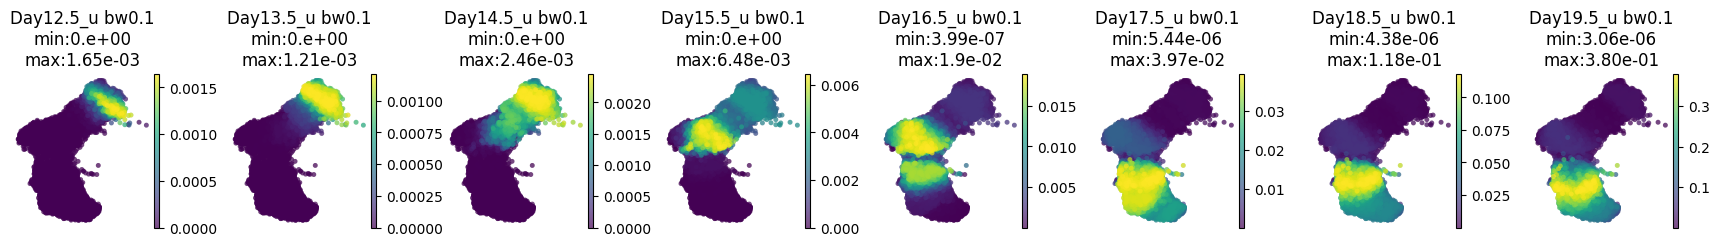

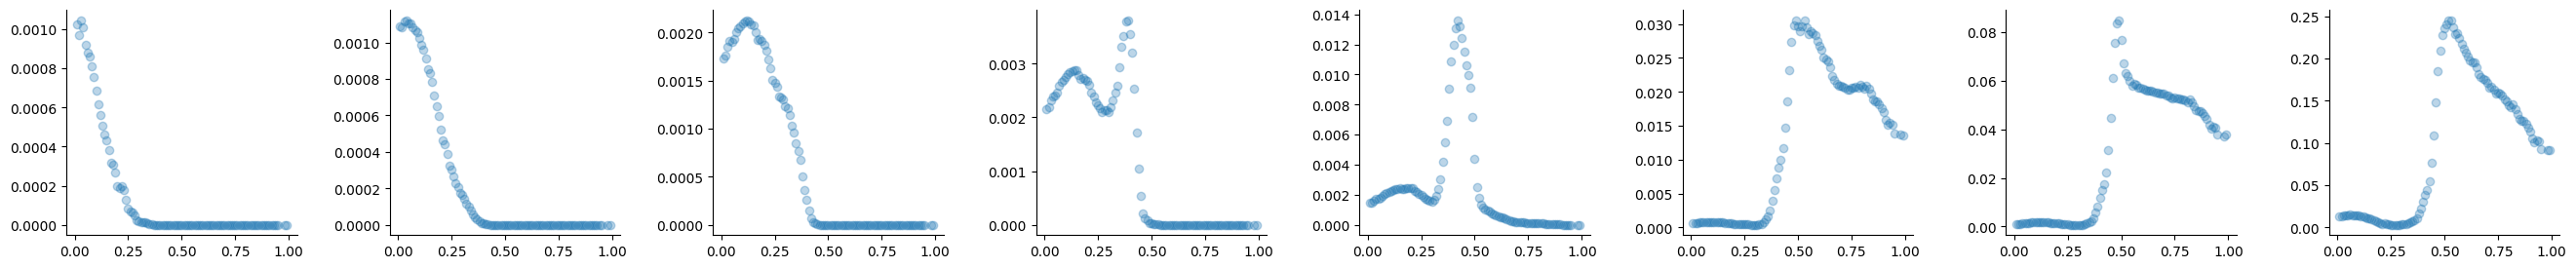

In [194]:
aggregate_params_by_pseudotime(u_b, f'u bw{bw}')

In [195]:
bw = 0.1
train_DS = reader.TwoTimpepoint_AnnDS(
                    AnnData=meahr_monocle, 
                    timepoint_idx=None, 
                    n_dimension = None,
                    timepoint_key='time',
                    cellstate_key='DM_EigenVectors_multiscaled',  #'DM_EigenVector'
                    log_transform=False,
                    norm_time='min_minus',
                    deltax_key='Delta_DM_std',
                    kde_kws = {"bw_method":bw},
                    batchsize=200)

u_monocle = train_DS.u_b.numpy()
n_timepoint = 8


Computing density :
`density_funs` not specified, use gaussian kde


prediction of shape (8, 10104)


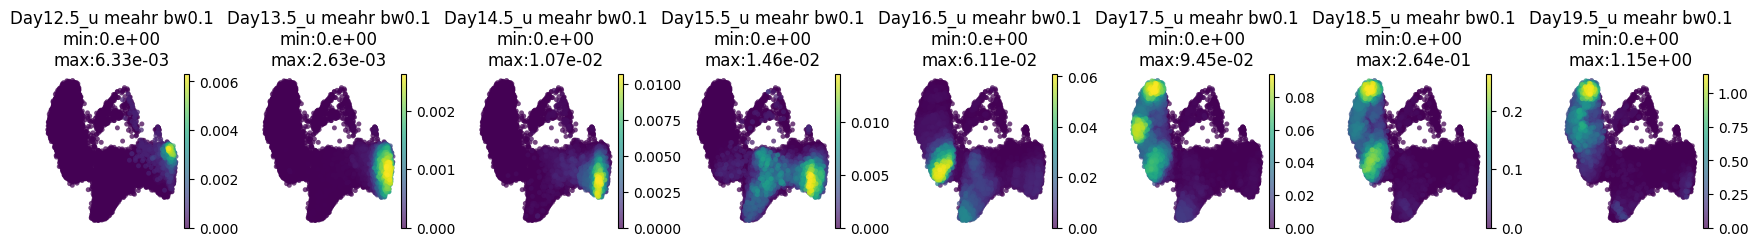

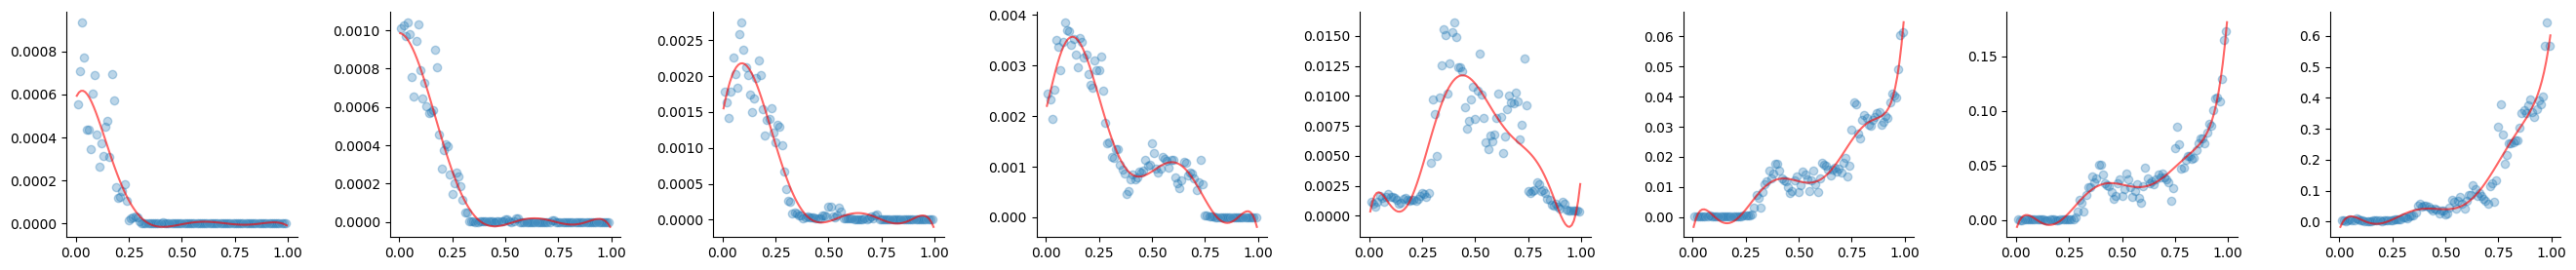

In [196]:
aggregate_params_by_pseudotime(u_monocle, f'u meahr bw{bw}', adata=meahr_monocle, pseudotime_key='pseudotime_scaled')

In [128]:
bw = 0.2
train_DM = reader.TwoTimpepoint_AnnDS(
                    AnnData=single_branch, 
                    timepoint_idx=None, 
                    n_dimension = 4,
                    cellstate_key='X_dc',  #'DM_EigenVector'
                    log_transform=False,
                    norm_time='min_minus',
                    deltax_key=None,
                    kde_kws = {"bw_method":bw},
                    batchsize=200)

u_dm = train_DS.u_b.numpy()
n_timepoint = 8
n_dimension = 3

Computing density :
`density_funs` not specified, use gaussian kde


prediction of shape (8, 9485)


prediction of shape (8, 9485)


/ssd/users/Wergillius/Project/PINN_dynamics/PINN/plotting_fns/param_plot.py:60: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  adata.obs[f'Day{t}_{param}'] = prediction[i]


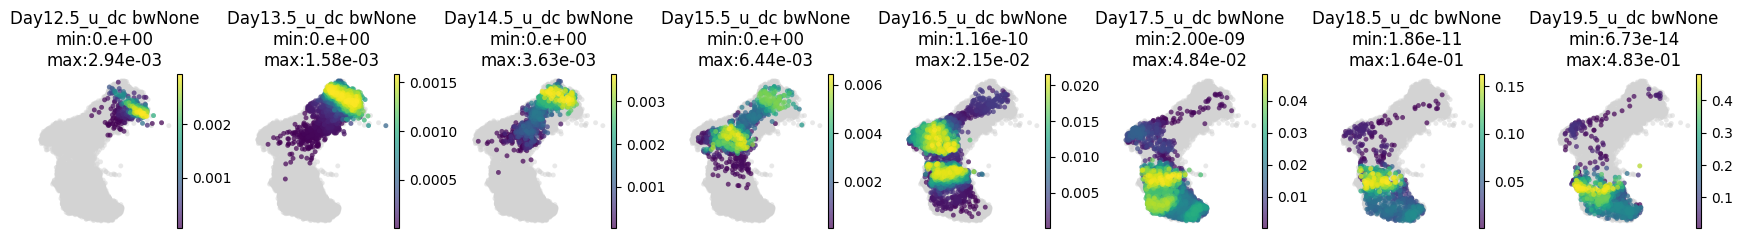

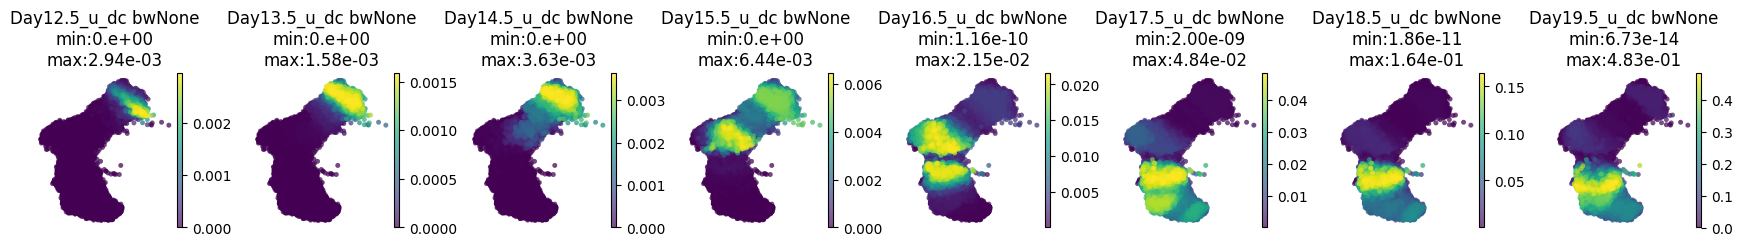

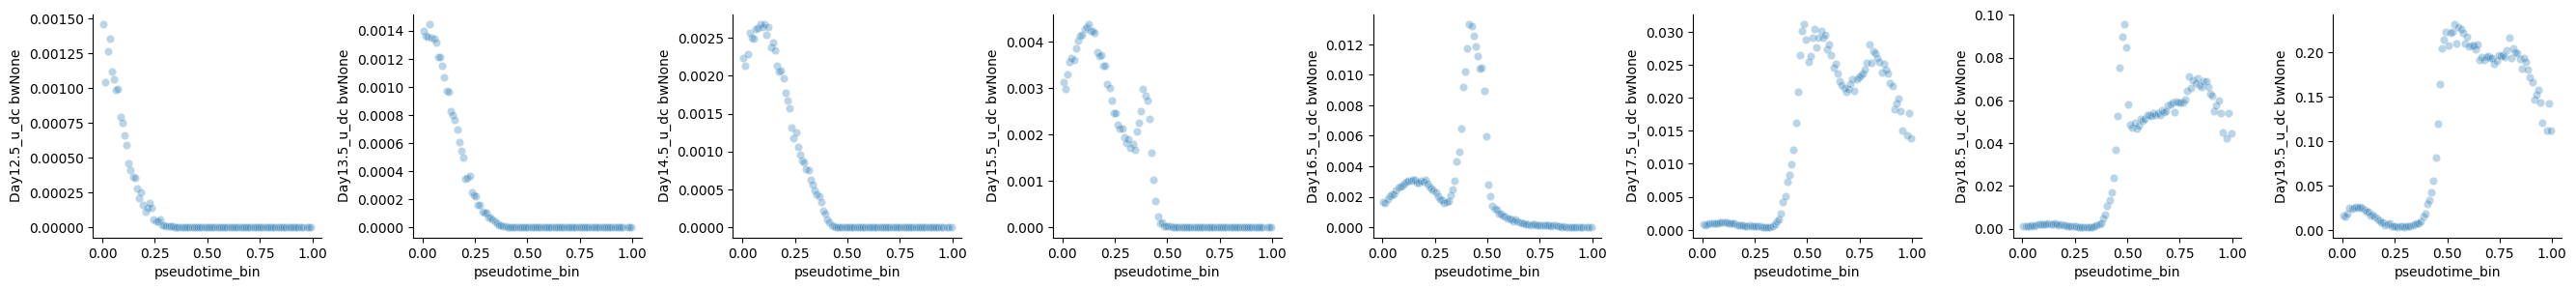

In [179]:
aggregate_params_by_pseudotime(u_dm, f'u_dc bw{bw}')

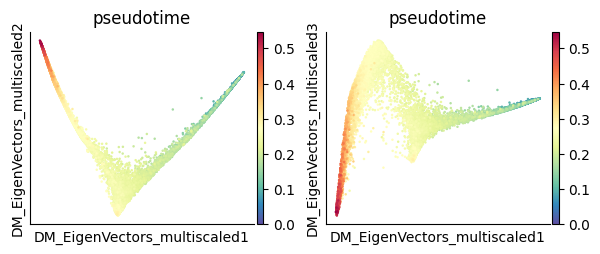

In [108]:
fig, axs = plt.subplots(1, 2, figsize=(7,2.5))

sc.pl.embedding(single_branch, basis='DM_EigenVectors_multiscaled', color='pseudotime', dimensions=[0,1], ax=axs[0], return_fig=False, show=False)
sc.pl.embedding(single_branch, basis='DM_EigenVectors_multiscaled', color='pseudotime', dimensions=[0,2], ax=axs[1], return_fig=False, show=False)
fig.show()

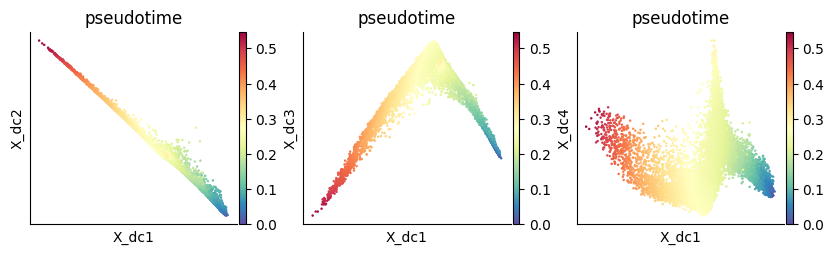

In [109]:
fig, axs = plt.subplots(1, 3 , figsize=(10,2.5))

sc.pl.embedding(single_branch, basis='X_dc', color='pseudotime', dimensions=[0,1], ax=axs[0], return_fig=False, show=False)
sc.pl.embedding(single_branch, basis='X_dc', color='pseudotime', dimensions=[0,2], ax=axs[1], return_fig=False, show=False)
sc.pl.embedding(single_branch, basis='X_dc', color='pseudotime', dimensions=[0,3], ax=axs[2], return_fig=False, show=False)
fig.show()

## load model

In [ ]:
device = 'cuda:3'

In [19]:
log_dir = "logs/David_non_branching-DM_EigenVectors_multiscaled_std_n8/pde_params_tsense/lightning_logs/"

v0_ckpt = f"{log_dir}/version_0/checkpoints/epoch=95-total_loss=24.32756996.ckpt" 
v1_ckpt = f"{log_dir}/version_1/checkpoints/epoch=121-total_loss=4.16667986.ckpt"
v2_ckpt = f"{log_dir}/version_2/checkpoints/epoch=174-total_loss=4.19242716.ckpt"
v3_ckpt = f"{log_dir}/version_3/checkpoints/epoch=247-total_loss=3.97555852.ckpt"

In [20]:
model_v0 = PINN.models.pde_params.load_from_checkpoint(v0_ckpt, map_location=device)
model_v1 = PINN.models.pde_params.load_from_checkpoint(v1_ckpt, map_location=device)
model_v2 = PINN.models.pde_params.load_from_checkpoint(v2_ckpt, map_location=device)
model_v3 = PINN.models.pde_params.load_from_checkpoint(v3_ckpt, map_location=device)

In [21]:
# short-term

In [22]:
pde_model = model_v0.to(device)

In [23]:
u_b = train_DS.u_b.numpy()
timepoint_idx = None
u_int_all = PINN.tl.density_shortterm_simulation(pde_model, train_DS, timepoints=train_DS.T_b/pde_model.time_scale_factor)
u_int_all = np.concatenate([u_b[0].reshape(1,-1), u_int_all], axis=0)

0it [00:00, ?it/s]

simulating from timepoint 0.0 to 0.2


simulating from timepoint 0.2 to 0.4
simulating from timepoint 0.4 to 0.6
simulating from timepoint 0.6 to 0.8
simulating from timepoint 0.8 to 1.0
simulating from timepoint 1.0 to 1.2
simulating from timepoint 1.2 to 1.4


prediction of shape (8, 9485)


prediction of shape (8, 9485)


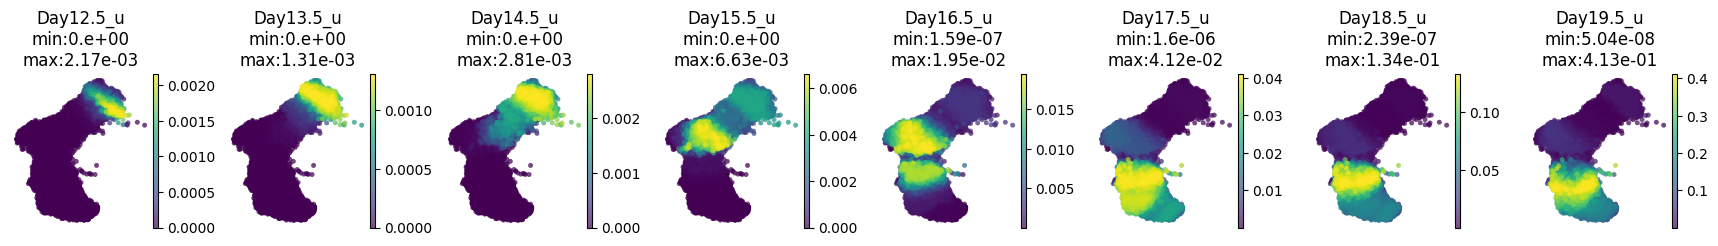

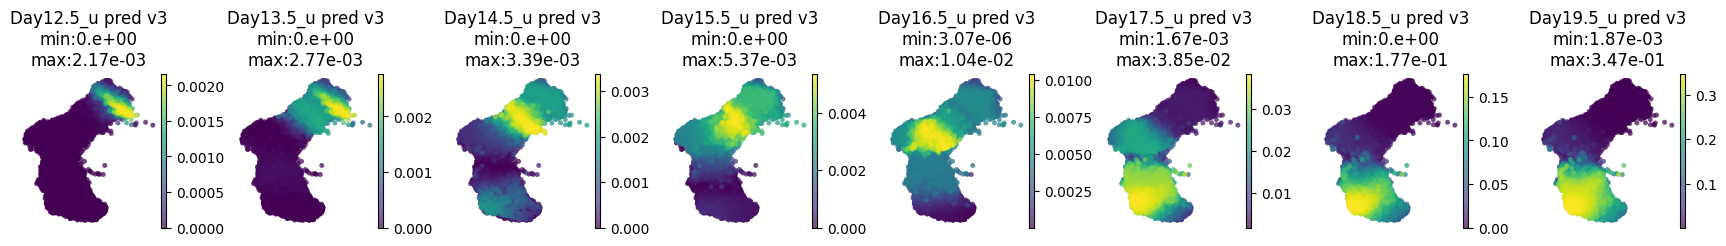

In [24]:
u_b = train_DS.u_b.numpy()
fig_param, axs_param = PINN.pl.params_in_umap(single_branch,
                        u_b, param='u', cell_of_t=False);

fig_param, axs_param = PINN.pl.params_in_umap(single_branch,
                        u_int_all, param='u pred v3', cell_of_t=False);

In [ ]:
def param_array(train_DS, pde_model):

    s_ts = train_DS.s.float().to(device)
    t_ts = train_DS.t_b.float().to(device)
    chunk_size = 5000

    u_pred_ls = []
    v_ls = []
    D_ls = []
    g_ls = []

    with torch.no_grad():
        for i in range(0, len(t_ts), chunk_size):                              
            s_in = s_ts[i:i+chunk_size]
            t_in = t_ts[i:i+chunk_size]

            v_pred = pde_model.v(s_in, t_in)
            g_pred = pde_model.g(s_in, t_in)
            D_pred = pde_model.D(s_in, t_in)
            
            v_ls.append(v_pred.detach().cpu().numpy())
            g_ls.append(g_pred.detach().cpu().numpy())
            D_ls.append(D_pred.detach().cpu().numpy())

            if "u" in dir(pde_model):
                u_pred = torch.exp(pde_model.u(s_in, t_in))
                u_pred_ls.append(u_pred.detach().cpu().numpy())

    v_pred_ay = np.concatenate(v_ls, axis=0).reshape(n_timepoint, -1, n_dimension) / pde_model.time_scale_factor
    g_pred_ay = np.concatenate(g_ls, axis=0).reshape(n_timepoint,-1) / pde_model.time_scale_factor
    D_pred_ay = np.concatenate(D_ls, axis=0).reshape(n_timepoint,-1) / pde_model.time_scale_factor

    return v_pred_ay, g_pred_ay, D_pred_ay

In [26]:
train_DS.deltax.shape

(9485, 3)

In [27]:
v_divide = np.divide(v_pred_ay, train_DS.deltax.reshape(1,-1,3)) 

/tmp/ipykernel_3581870/797089268.py:1: RuntimeWarning: divide by zero encountered in divide
  v_divide = np.divide(v_pred_ay, train_DS.deltax.reshape(1,-1,3))


In [28]:
v_norm2 = np.sqrt(np.power(v_pred_ay,2).mean(axis=2))

In [29]:
v_norm2.shape

(8, 9485)

prediction of shape (8, 9485)


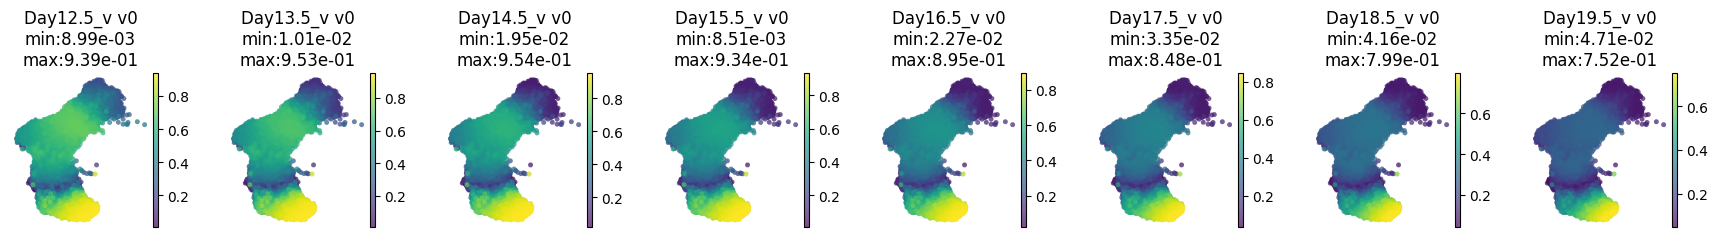

In [30]:
fig_param, axs_param = PINN.pl.params_in_umap(single_branch, v_norm2, param='v v0', copy=False,cell_of_t=False);

prediction of shape (8, 9485)


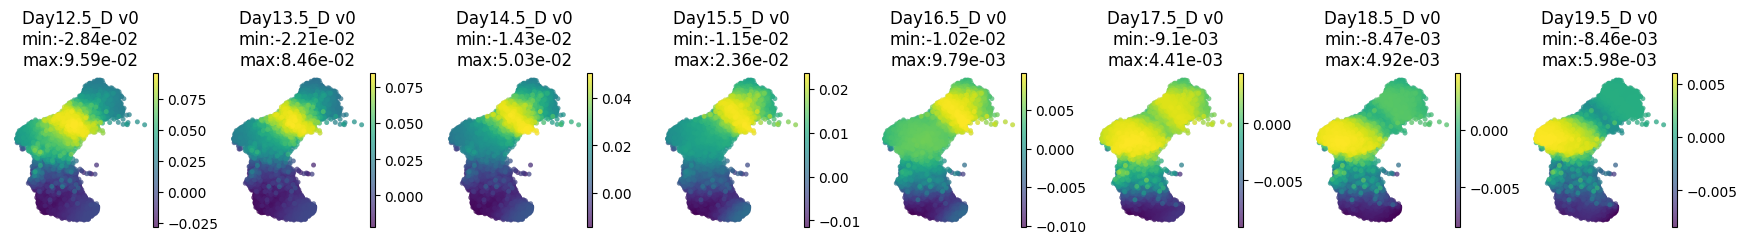

In [31]:
fig_param, axs_param = PINN.pl.params_in_umap(single_branch, D_pred_ay, param='D v0', copy=False,cell_of_t=False);

prediction of shape (8, 9485)


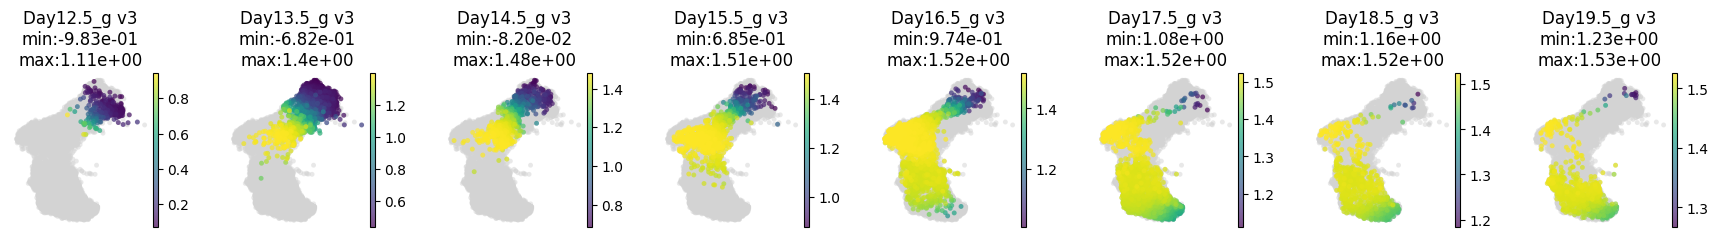

In [32]:
fig_param, axs_param = PINN.pl.params_in_umap(single_branch, g_pred_ay, param='g v3', cell_of_t=True);

prediction of shape (8, 9485)


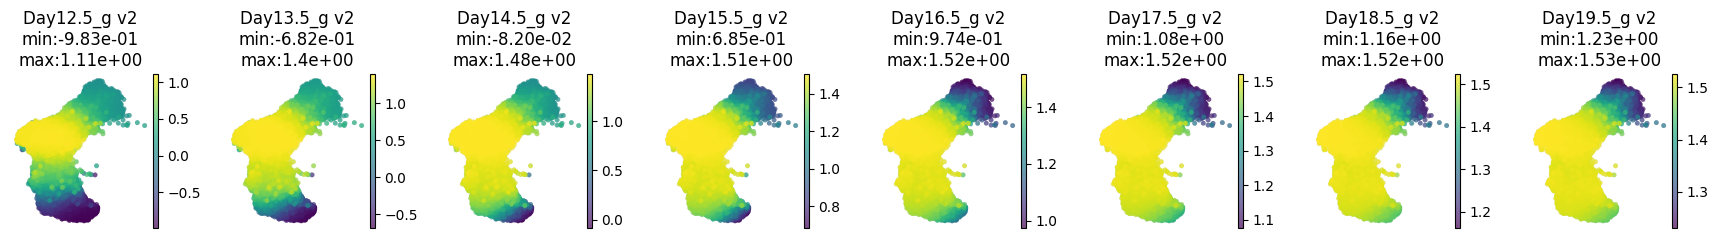

In [33]:
fig_param, axs_param = PINN.pl.params_in_umap(single_branch, g_pred_ay, param='g v2', copy=False,cell_of_t=False);

prediction of shape (8, 9485)


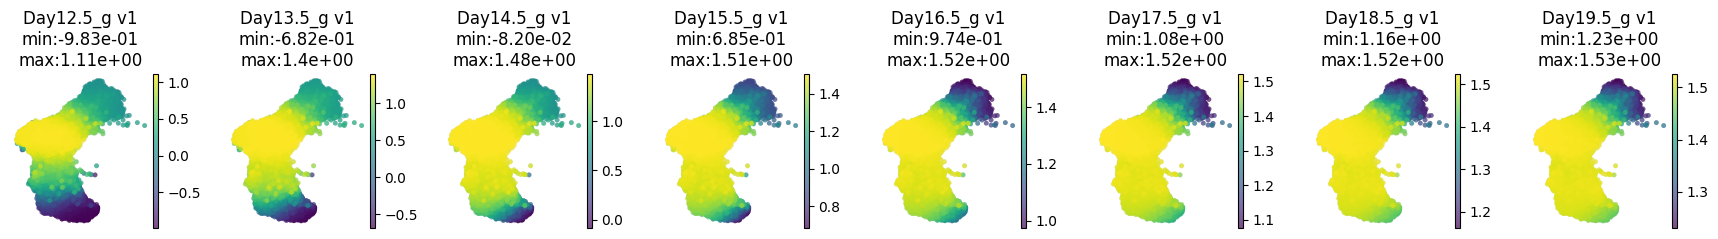

In [34]:
fig_param, axs_param = PINN.pl.params_in_umap(single_branch, g_pred_ay, param='g v1', copy=False,cell_of_t=False);

prediction of shape (8, 9485)


NameError: name 'plt' is not defined

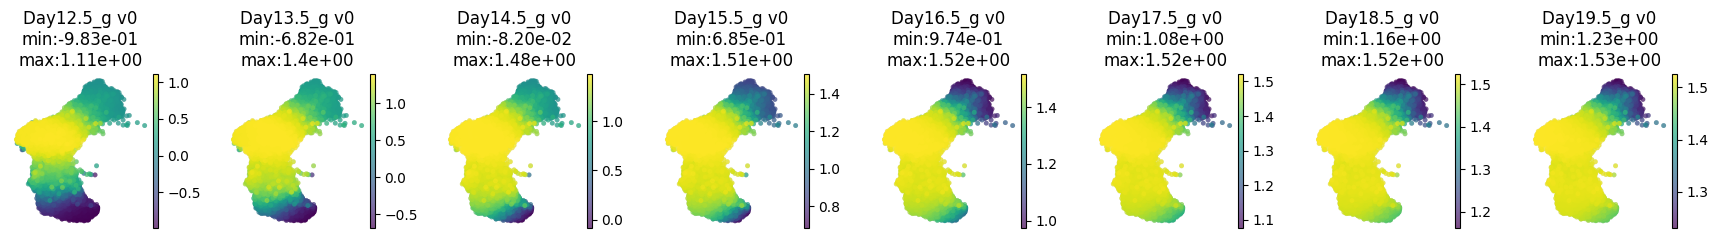

In [35]:
fig_param, axs_param = PINN.pl.params_in_umap(single_branch, g_pred_ay, param='g v0', copy=False,cell_of_t=False);
aggregate_params_by_pseudotime('Day%s_g v0')

In [36]:
import matplotlib.pyplot as plt

In [37]:
pdt_bins = np.linspace(0,1,301)
pdt_label = (pdt_bins[1:] + pdt_bins[:1])/2
single_branch.obs['pseudotime_bin'] = pd.cut(single_branch.obs['palantir_pseudotime'], bins=300,
                                             labels = pdt_label)

In [38]:
len(pdt_label)

300

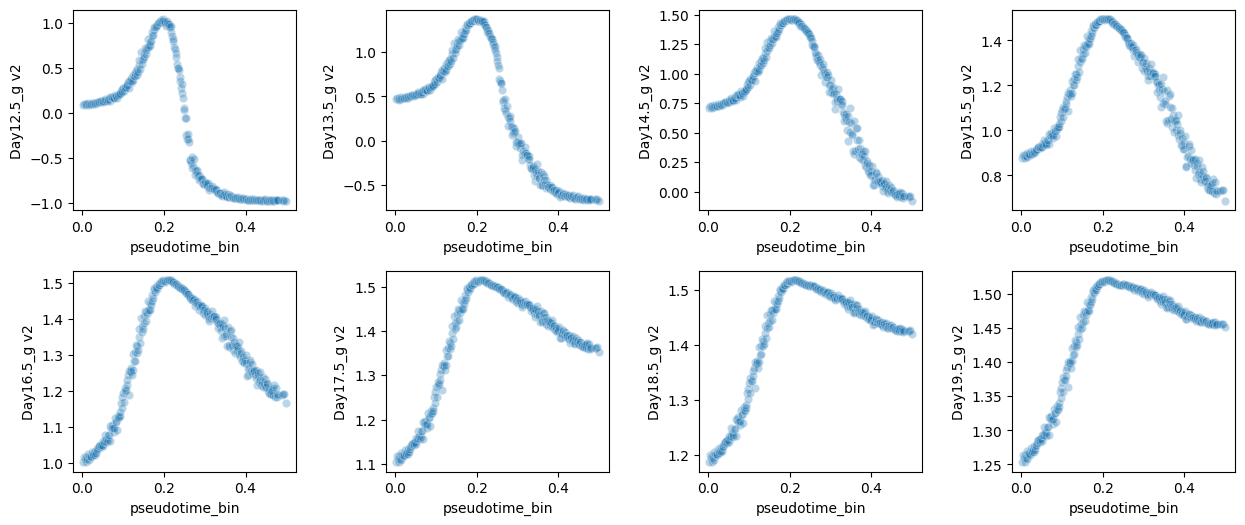

In [40]:
pdt_bins = np.linspace(0,1,301)
pdt_label = (pdt_bins[1:] + pdt_bins[:1])/2
single_branch.obs['pseudotime_bin'] = pd.cut(single_branch.obs['pseudotime'], bins=300,
                                             labels = pdt_label)

fig, axs = plt.subplots(2,4, figsize=(15,6), gridspec_kw={"wspace":0.4, 'hspace':0.3})
axs = axs.flatten()
for i,t in enumerate(single_branch.uns['pop']['t']):
    data = single_branch.obs[['pseudotime_bin', 'Day%s_g v2'%t]]
    gdata = data.groupby("pseudotime_bin").agg("mean").reset_index()
    sns.scatterplot(data=gdata, x='pseudotime_bin', y='Day%s_g v2'%t, ax=axs[i], alpha=0.3)

In [41]:
single_branch

AnnData object with n_obs × n_vars = 9485 × 7102
    obs: 'barcodes', 'batch_x', 'pseudodynamics_branching_region', 'pseudodynamics_branch_class', 'dpt_adjusted_groups', 'time', 'batch_y', 'pseudotime', 'cell', 'dc1', 'dc2', 'dc3', 'dc4', 'batch_to_match', 'leiden', 'Time_x', 'Time_y', 'dpt_pseudotime', 'dpt_groups', 'dpt_order', 'dpt_order_indices', 'palantir_pseudotime', 'palantir_entropy', 'timepoint_tx_days', 'u_12.5', 'u_13.5', 'u_14.5', 'u_15.5', 'u_16.5', 'u_17.5', 'u_18.5', 'u_19.5', 'Day12.5_v v0', 'Day13.5_v v0', 'Day14.5_v v0', 'Day15.5_v v0', 'Day16.5_v v0', 'Day17.5_v v0', 'Day18.5_v v0', 'Day19.5_v v0', 'Day12.5_D v0', 'Day13.5_D v0', 'Day14.5_D v0', 'Day15.5_D v0', 'Day16.5_D v0', 'Day17.5_D v0', 'Day18.5_D v0', 'Day19.5_D v0', 'Day12.5_g v2', 'Day13.5_g v2', 'Day14.5_g v2', 'Day15.5_g v2', 'Day16.5_g v2', 'Day17.5_g v2', 'Day18.5_g v2', 'Day19.5_g v2', 'Day12.5_g v1', 'Day13.5_g v1', 'Day14.5_g v1', 'Day15.5_g v1', 'Day16.5_g v1', 'Day17.5_g v1', 'Day18.5_g v1', 'Day19.

In [42]:
cellcycle = pd.read_table("data/mouse_geneset/regev_lab_cell_cycle_gene_mouse.txt", names=['gene'])

In [43]:
genes = cellcycle['gene'].values

In [44]:
s_gene = genes[:44]
g2m_gene = genes[44:]

In [45]:
sc.tl.score_genes_cell_cycle(single_branch, s_genes = s_gene, g2m_genes = g2m_gene)

In [46]:
pdt_bins = np.linspace(0,1,11)
pdt_label = (pdt_bins[1:] + pdt_bins[:1])/2
single_branch.obs['pseudotime_bin'] = pd.cut(single_branch.obs['pseudotime'], bins=10,
                                             labels = pdt_label)

In [92]:
def cellcycle_stackbar(adata, time_col='pseudotime_bin'):
    
    df = adata.obs.groupby([time_col,'phase']).agg({'batch_y':'count'}).reset_index()
    
    n_bar = df[time_col].nunique()
    x = df[time_col].unique()

    dfs = []
    for t in x:
        df_t = df.query(f"`{time_col}` == @t")
        total = df_t.batch_y.values.sum()
        df_t.loc[:,'proportion'] = df_t['batch_y'] / total ;

        dfs.append(df_t)

    normed_df = pd.concat(dfs)


    base = np.zeros((n_bar,))

    for phase in normed_df.phase.unique():
        
        pro_t = normed_df.query('`phase` == @phase')
        height = pro_t.sort_values(time_col)['proportion'].values

        plt.bar(x=range(n_bar), height=height, label=phase, bottom=base, width=0.7)

        base += height

        plt.xticks(ticks=range(n_bar),labels=np.around(x,3))

    plt.legend(bbox_to_anchor=(1,0.4,0.3,0.1))

/tmp/ipykernel_3581870/3634918386.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_t.loc[:,'proportion'] = df_t['batch_y'] / total ;
/tmp/ipykernel_3581870/3634918386.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_t.loc[:,'proportion'] = df_t['batch_y'] / total ;
/tmp/ipykernel_3581870/3634918386.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http

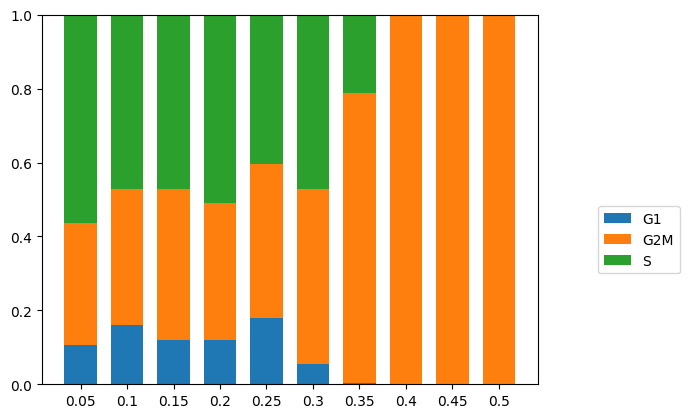

In [ ]:
cellcycle_stackbar(single_branch, 'pseudotime_bin');

/tmp/ipykernel_3581870/3634918386.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_t.loc[:,'proportion'] = df_t['batch_y'] / total ;
/tmp/ipykernel_3581870/3634918386.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_t.loc[:,'proportion'] = df_t['batch_y'] / total ;
/tmp/ipykernel_3581870/3634918386.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http

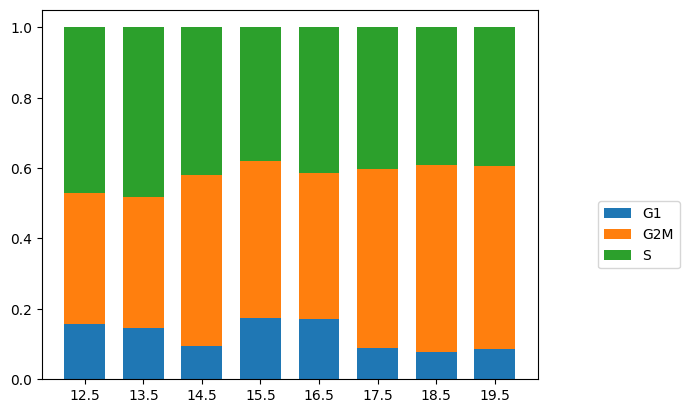

In [94]:
cellcycle_stackbar(single_branch, 'time');